# 06 · Variational Inference: Bayes by Backprop (PyTorch)

*Companion notebook for the chapter sections* **Approximations for Estimation · Software for BNN — PyTorch**

MCMC samples the posterior exactly but slowly. **Variational inference (VI)** turns inference into *optimisation*, so it scales to real networks and plugs into ordinary deep-learning tools.
Here we implement **Bayes by Backprop** (Blundell et al., 2015) with nothing but plain PyTorch.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
print("PyTorch", torch.__version__)

PyTorch 2.14.0+cu130


## 1. The idea

Choose a simple family $q_{\boldsymbol\theta}(\mathbf w)$ — here an independent Gaussian for every weight, $w_j\sim\mathcal N(\mu_j,\sigma_j^2)$ — and make it as close as possible to the true posterior by minimising the KL divergence.
This is equivalent to maximising the **evidence lower bound (ELBO)**:

$$\mathcal L(\boldsymbol\theta)=\underbrace{\mathbb E_{q_{\boldsymbol\theta}(\mathbf w)}\big[\log p(\mathcal D\mid\mathbf w)\big]}_{\text{fit the data}}-\underbrace{\mathrm{KL}\big(q_{\boldsymbol\theta}(\mathbf w)\,\big\|\,p(\mathbf w)\big)}_{\text{stay close to the prior}}\;\le\;\log p(\mathcal D).$$

Each weight now has **two** trainable numbers: a mean $\mu$ and a standard deviation $\sigma=\operatorname{softplus}(\rho)=\log(1+e^\rho)$, which is always positive.

**Reparameterisation trick.** To backpropagate through a random draw, write $w=\mu+\sigma\,\varepsilon$ with $\varepsilon\sim\mathcal N(0,1)$. The randomness sits in $\varepsilon$, so gradients flow to $\mu$ and $\rho$.

**Closed-form KL.** For $q=\mathcal N(\mu,\sigma^2)$ and prior $p=\mathcal N(0,s^2)$:
$\;\mathrm{KL}=\log\frac s\sigma+\frac{\sigma^2+\mu^2}{2s^2}-\frac12 .$

In [2]:
class BayesianLinear(nn.Module):
    '''A linear layer whose weights and biases are independent Gaussians.'''
    def __init__(self, d_in, d_out, prior_std=1.0):
        super().__init__()
        self.w_mu  = nn.Parameter(torch.empty(d_out, d_in).normal_(0, 1 / math.sqrt(d_in)))
        self.w_rho = nn.Parameter(torch.full((d_out, d_in), -5.0))   # softplus(-5) ≈ 0.007: start almost deterministic
        self.b_mu  = nn.Parameter(torch.zeros(d_out))
        self.b_rho = nn.Parameter(torch.full((d_out,), -5.0))
        self.prior_std = prior_std

    def forward(self, x):
        w_sigma, b_sigma = F.softplus(self.w_rho), F.softplus(self.b_rho)
        w = self.w_mu + w_sigma * torch.randn_like(w_sigma)          # reparameterisation trick
        b = self.b_mu + b_sigma * torch.randn_like(b_sigma)
        return F.linear(x, w, b)

    def kl(self):
        s = self.prior_std
        total = 0.0
        for mu, rho in [(self.w_mu, self.w_rho), (self.b_mu, self.b_rho)]:
            sigma = F.softplus(rho)
            total = total + (torch.log(s / sigma) + (sigma**2 + mu**2) / (2 * s**2) - 0.5).sum()
        return total


class BNN(nn.Module):
    def __init__(self, hidden=64, prior_std=1.0):
        super().__init__()
        self.l1 = BayesianLinear(1, hidden, prior_std)
        self.l2 = BayesianLinear(hidden, hidden, prior_std)
        self.l3 = BayesianLinear(hidden, 1, prior_std)
        self.log_noise = nn.Parameter(torch.tensor(-2.3))           # learned aleatoric noise (point estimate)

    def forward(self, x):
        return self.l3(torch.tanh(self.l2(torch.tanh(self.l1(x))))).squeeze(-1)

    def kl(self):
        return self.l1.kl() + self.l2.kl() + self.l3.kl()

## 2. Data

In [3]:
rng = np.random.default_rng(1)
x_np = np.concatenate([rng.uniform(-4, -1.5, 250), rng.uniform(1.5, 4, 250)])   # 500 points (see section 7 for why)
y_np = np.sin(x_np) + 0.1 * rng.standard_normal(len(x_np))
x_t = torch.tensor(x_np, dtype=torch.float32)[:, None]
y_t = torch.tensor(y_np, dtype=torch.float32)
xg = torch.linspace(-8, 8, 400)[:, None]
N = len(x_t)

## 3. Training: minimise the negative ELBO

Using one Monte-Carlo sample of the weights per step:

$$-\mathcal L\approx-\sum_{i=1}^N\log\mathcal N\big(y_i\mid f_{\mathbf w}(x_i),\sigma_{\text{noise}}^2\big)+\mathrm{KL}(q\,\|\,p),\qquad \mathbf w\sim q_{\boldsymbol\theta}.$$

We divide everything by $N$ so the learning rate does not depend on the data-set size. With mini-batches, the KL term is shared across the batches of one epoch.

In [4]:
model = BNN(hidden=32, prior_std=1.0)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
history = {"nll": [], "kl": []}

for step in range(6000):
    opt.zero_grad()
    pred = model(x_t)
    noise = model.log_noise.exp()
    nll = -torch.distributions.Normal(pred, noise).log_prob(y_t).sum()
    kl = model.kl()
    loss = (nll + kl) / N
    loss.backward(); opt.step()
    history["nll"].append(nll.item()); history["kl"].append(kl.item())
    if step % 1500 == 0:
        print(f"step {step:4d}   NLL {nll.item():9.2f}   KL {kl.item():8.2f}   noise σ {noise.item():.3f}")
print(f"final noise σ = {model.log_noise.exp().item():.3f}   (true value 0.1)")

step    0   NLL  28124.36   KL  5226.29   noise σ 0.100


step 1500   NLL   -152.89   KL  1531.61   noise σ 0.209


step 3000   NLL    -28.36   KL   640.62   noise σ 0.247


step 4500   NLL      3.45   KL   480.41   noise σ 0.253


final noise σ = 0.227   (true value 0.1)


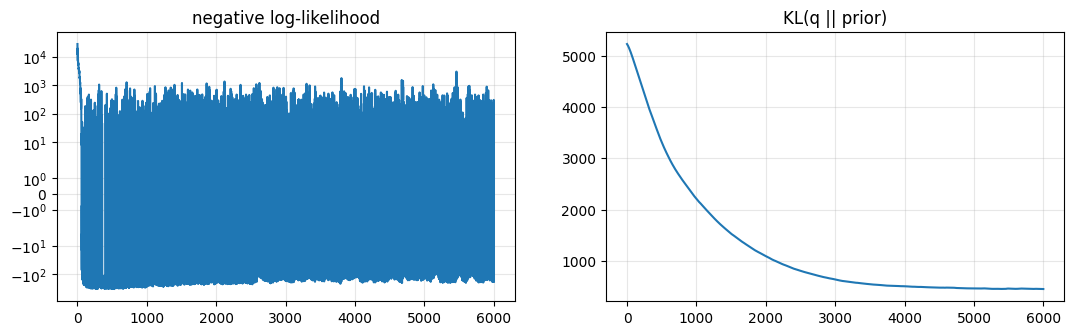

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].plot(history["nll"]); ax[0].set_yscale("symlog"); ax[0].set_title("negative log-likelihood")
ax[1].plot(history["kl"]); ax[1].set_title("KL(q || prior)")
plt.show()

## 4. Predicting with a BNN = averaging many sampled networks

Every forward pass draws fresh weights. Running $T$ passes gives $T$ functions; their spread is the **epistemic** uncertainty, and the learned noise $\sigma_{\text{noise}}$ is the **aleatoric** part.

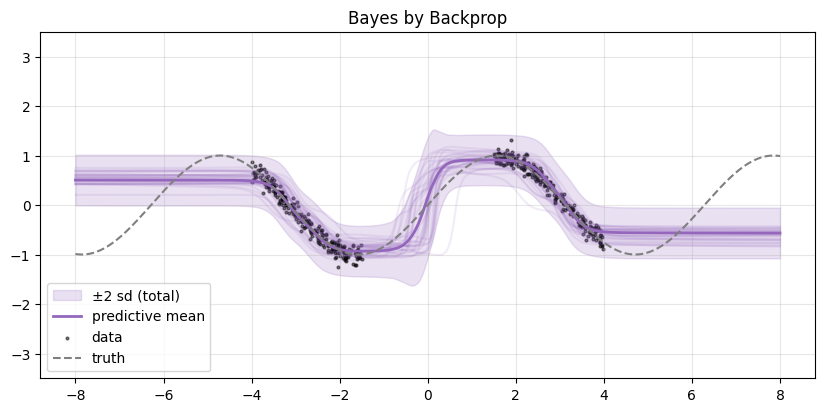

In [6]:
T = 300
with torch.no_grad():
    samples = torch.stack([model(xg) for _ in range(T)]).numpy()      # (T, 400)
    noise = model.log_noise.exp().item()
mu, epi = samples.mean(0), samples.std(0)
tot = np.sqrt(epi**2 + noise**2)
xs = xg.squeeze().numpy()

fig, ax = plt.subplots(figsize=(10, 4.5))
for s in samples[:30]:
    ax.plot(xs, s, c="C4", alpha=0.12)
ax.fill_between(xs, mu - 2 * tot, mu + 2 * tot, color="C4", alpha=0.2, label="±2 sd (total)")
ax.plot(xs, mu, c="C4", lw=2, label="predictive mean")
ax.scatter(x_np, y_np, c="k", s=4, alpha=0.5, label="data")
ax.plot(xs, np.sin(xs), "--", c="gray", label="truth")
ax.set_ylim(-3.5, 3.5); ax.legend(loc="lower left"); ax.set_title("Bayes by Backprop")
plt.show()

**Read the plot critically.** Two things are typical of mean-field VI:
the learned noise $\sigma_{\text{noise}}$ comes out larger than the true 0.1 (the KL cost makes the model absorb some signal as noise), and far from the data the predictive flattens with a band that is narrower than MCMC gave in notebook 05. The approximation is fast and useful, but it is *over-confident* compared with the exact posterior.

## 5. What did the network learn about its weights?

The learned standard deviations show which weights the data pinned down (small $\sigma$) and which remain uncertain (large $\sigma$, close to the prior).
Weights with a high signal-to-noise ratio $|\mu|/\sigma$ matter; low-SNR weights can often be pruned.

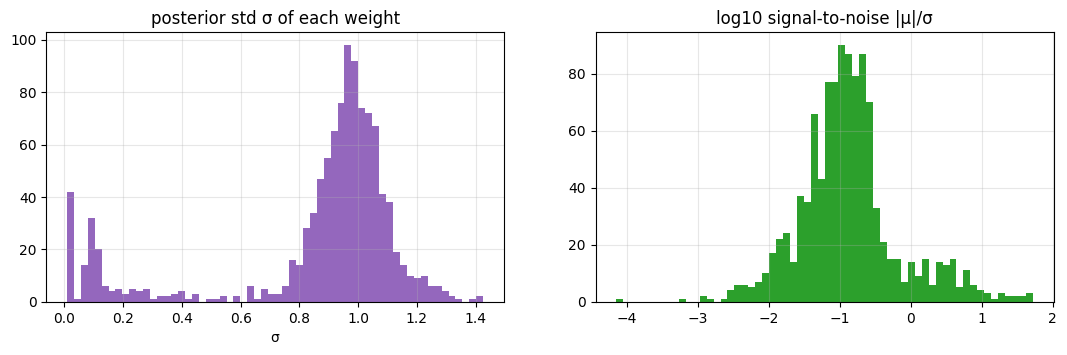

In [7]:
sig = torch.cat([F.softplus(l.w_rho).flatten() for l in [model.l1, model.l2, model.l3]]).detach().numpy()
mus = torch.cat([l.w_mu.flatten() for l in [model.l1, model.l2, model.l3]]).detach().numpy()
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].hist(sig, bins=60, color="C4"); ax[0].set_title("posterior std σ of each weight"); ax[0].set_xlabel("σ")
ax[1].hist(np.log10(np.abs(mus) / sig + 1e-12), bins=60, color="C2"); ax[1].set_title("log10 signal-to-noise |μ|/σ")
plt.show()

## 6. Compare with an ordinary network

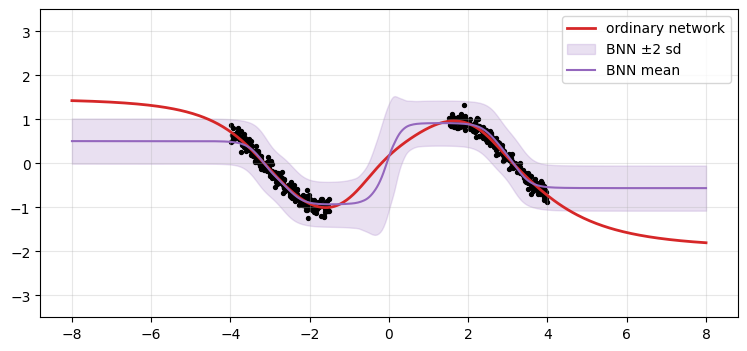

In [8]:
det = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
opt_d = torch.optim.Adam(det.parameters(), lr=1e-2)
for _ in range(3000):
    opt_d.zero_grad(); l = F.mse_loss(det(x_t).squeeze(-1), y_t); l.backward(); opt_d.step()

with torch.no_grad():
    yd = det(xg).squeeze().numpy()
plt.plot(xs, yd, c="C3", lw=2, label="ordinary network")
plt.fill_between(xs, mu - 2 * tot, mu + 2 * tot, color="C4", alpha=0.2, label="BNN ±2 sd")
plt.plot(xs, mu, c="C4", label="BNN mean")
plt.scatter(x_np, y_np, c="k", s=8); plt.ylim(-3.5, 3.5); plt.legend(); plt.show()

## 7. A lesson about data: when the KL term wins

The ELBO balances two terms. Every weight whose $\sigma$ is pulled far below the prior costs roughly $\log(s/\sigma)$ nats of KL, while the data term grows with $N$.
With **few data points and many weights**, the cheapest solution is to stay close to the prior and explain everything as noise — the BNN *underfits*.
We retrain on only 60 points to see it.

learned noise with 60 points: 1.07  (true 0.1)


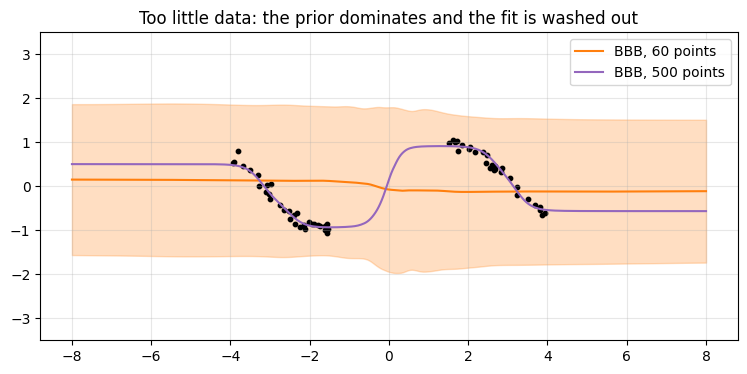

In [9]:
def train_bbb(x_np, y_np, steps=6000, hidden=32):
    xt = torch.tensor(x_np, dtype=torch.float32)[:, None]; yt = torch.tensor(y_np, dtype=torch.float32)
    torch.manual_seed(0); m = BNN(hidden=hidden); o = torch.optim.Adam(m.parameters(), lr=1e-2)
    for _ in range(steps):
        o.zero_grad()
        nll = -torch.distributions.Normal(m(xt), m.log_noise.exp()).log_prob(yt).sum()
        ((nll + m.kl()) / len(xt)).backward(); o.step()
    return m

idx = rng.choice(N, 60, replace=False)
small = train_bbb(x_np[idx], y_np[idx])
with torch.no_grad():
    S = torch.stack([small(xg) for _ in range(200)]).numpy()
print(f"learned noise with 60 points: {small.log_noise.exp().item():.2f}  (true 0.1)")
plt.fill_between(xs, S.mean(0) - 2 * S.std(0), S.mean(0) + 2 * S.std(0), color="C1", alpha=0.25)
plt.plot(xs, S.mean(0), c="C1", label="BBB, 60 points")
plt.plot(xs, mu, c="C4", label="BBB, 500 points")
plt.scatter(x_np[idx], y_np[idx], c="k", s=10); plt.ylim(-3.5, 3.5); plt.legend()
plt.title("Too little data: the prior dominates and the fit is washed out"); plt.show()

Common remedies: fewer weights, more data, a prior scaled to each layer's width, or down-weighting the KL term ("KL annealing" / tempered posteriors — a practical but no longer strictly Bayesian choice). MCMC (notebook 05) handled 40 points fine because it does not have to pay for a restricted approximating family.

## Notes and caveats

* **Mean-field VI tends to be over-confident**, especially *between* clusters of data (Foong et al., 2019). The Gaussian family cannot represent correlated, multi-modal posteriors like the ones MCMC revealed in notebook 05.
* The **prior** matters: try `prior_std=0.1` and `prior_std=5`.
* Ready-made libraries: [`torchbnn`](https://github.com/Harry24k/bayesian-neural-network-pytorch), [`blitz-bayesian-pytorch`](https://github.com/piEsposito/blitz-bayesian-deep-learning), and probabilistic programming with [Pyro](https://pyro.ai).

## Exercises
1. Replace the fixed Gaussian prior by the **scale-mixture prior** of Blundell et al. (2015): $\pi\,\mathcal N(0,s_1^2)+(1-\pi)\,\mathcal N(0,s_2^2)$. The KL then has no closed form — estimate it with the Monte-Carlo sample $\log q(\mathbf w)-\log p(\mathbf w)$.
2. Train with mini-batches of 16 points. How must the KL term be scaled?
3. Make the noise **heteroscedastic**: let the network output both a mean and $\log\sigma(x)$.